# Marketing Measurement & Incrementality Analysis in the DACH Region

### Simulating a Measurement Implementation Expert workflow for a privacy-first advertising environment

---

## 1. Business Context

Privacy changes across Europe, driven by **GDPR**, have fundamentally shifted how digital advertising performance is measured.

In privacy-conscious markets such as Germany, where data protection (*Datenschutz*) plays an important role in both regulation and consumer expectations, user-level tracking has become increasingly limited. As a result, marketers can no longer rely only on traditional attribution models to understand whether their campaigns are driving real business impact.

This project simulates the role of a **Measurement Implementation Expert** supporting a mid-size
e-commerce company operating across the DACH region: **Germany**, **Austria** and **Switzerland**.

The client has been running **Google Ads campaigns** consistently, but leadership is questioning
whether the observed conversions are truly incremental, or whether users would have converted anyway,
with or without advertising exposure.

To answer this, the analysis applies a modern measurement stack:

- **Conversion Lift studies** to isolate true incremental impact
- **Statistical significance testing** to validate results
- **Marketing Mix Modeling (MMM)** to estimate long-term channel contribution
- **SQL-based reporting** to surface actionable performance insights
- **ROI analysis** to support data-driven budget decisions

The primary goal is to understand how our ads influence the user journey across different markets, moving beyond simple 'last-click' metrics to identify which platforms serve as true assisted channels.


### 1.1 The Business Problem

The company wants answers to three core questions:

> **1.** Are Google Ads campaigns generating *incremental* conversions or just capturing existing demand?
>
> **2.** Which marketing channels contribute most to business outcomes across the DACH region?
>
> **3.** How should budgets be allocated across Germany, Austria and Switzerland to maximize return?

These questions sit at the heart of modern marketing measurement and they cannot be answered
through standard attribution reporting alone.

### 1.2 Why the DACH Region Is Particularly Interesting

The DACH market is not a single homogeneous audience. Each country has a distinct consumer profile that directly affects how advertising
performs and how measurement results should be interpreted.

Skepticism toward advertising is actually a shared DACH trait: consumers across all three markets tend to compare carefully, look for proof before buying, and respond poorly to vague promotional messaging. But the intensity of this behavior varies significantly by country.

| | 🇩🇪 Germany | 🇦🇹 Austria | 🇨🇭 Switzerland |
|---|---|---|---|
| **Ad receptiveness** | Lower | Medium | Higher |
| **Digital engagement** | Moderate | Moderate | Strong |
| **Purchasing power** | High | Medium | Very high |
| **Market role in simulation** | Scale market | Mid-tier | Efficiency leader |

---

**Germany** tends to be the most skeptical market of the group. German consumers generally prefer informative and transparent communication, place a strong emphasis on data protection, and are often less responsive to persuasion-driven ads. This shows up clearly in
lower click-through rates and longer decision cycles.

**Austria** shares many of these tendencies
but with a slightly younger demographic profile and more openness to digital engagement.

**Switzerland** shows the strongest digital engagement
and significantly higher purchasing power, making it the highest ROI market in this analysis.

Having lived in Germany and worked closely with German-speaking professionals for years, I have observed how privacy expectations influence both consumer behavior and measurement practices. Understanding these cultural and regulatory factors is essential when interpreting campaign performance and communicating measurement results to clients.

### 1.3 Analysis Scope

To answer the business questions, I designed an analysis workflow that covers everything from data exploration to budget recommendations. The table below outlines the methods used and their business goals:

| Step | Method | Business Purpose |
|------|--------|-----------------|
| Exploratory Analysis | EDA, KPI calculation | Understand baseline performance and seasonality |
| Incrementality Testing | Conversion Lift study | Isolate true advertising impact |
| Statistical Validation | Two-proportion Z-test | Confirm results are statistically solid (not just luck) |
| Channel Contribution | MMM with Adstock | Estimate long-term impact per channel |
| SQL Reporting | CTEs, Window Functions | Surface ROI insights and performance rankings |
| Budget Optimization | ROI-based allocation | Translate findings into actionable recommendations |

---

> Due to privacy standards, I focused on a market-level comparison using aggregated data rather than individual tracking. In a real-world scenario, after comparing performance across countries, my next step would be to perform a granular analysis, segmenting by specific regions, age groups, and purchasing power to further refine the media mix.


**Dataset:**
- 3 years of simulated daily marketing data
- 1,095 observations
- 3 DACH markets  

**Note:** Real advertiser data is confidential. This simulation reproduces realistic business patterns to demonstrate the full measurement workflow.

## 2. Setup and Data Generation

The dataset was simulated to reflect realistic DACH market conditions, including regional differences
in advertising engagement, seasonality effects and channel mix.

All observations represent daily
aggregated performance across Germany, Austria and Switzerland over a three-year period.

In [70]:
import pandas as pd
import numpy as np
import sqlite3
import scipy.stats as stats
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from itertools import product

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# ── Visual style ───────────────────────
plt.rcParams.update({"figure.facecolor": "white",
    "axes.facecolor":   "white","axes.spines.top":  False,
    "axes.spines.right": False,"axes.grid":        True,
    "grid.alpha":       0.3,"font.family":      "sans-serif",
    "axes.titlesize":   13,"axes.labelsize":   11,})

COLORS = {"DE": "#4A90D9",   # Germany
    "AT": "#50B87A",   # Austria
    "CH": "#E8845A",   # Switzerland
    "primary":  "#4A90D9","accent":   "#E8845A","neutral":  "#A0A0A0",}

### 2.1 Simulating Regional Behavior

Each DACH market was assigned distinct baseline parameters to reflect real consumer behavior patterns.

Germany's lower engagement rates are modeled intentionally: the simulation captures the well-known
tendency of German consumers to interact less with display and search advertising compared to
neighboring markets, a pattern that shapes how measurement results should be interpreted.

> **Note on budget design:** spend was equalized across all three markets to isolate
> behavioral differences. In a real-world scenario, Germany's budget would be substantially
> larger given its population of ~84M versus ~9M each in Austria and Switzerland.

In [71]:
np.random.seed(42)
dates = pd.date_range(start="2022-01-01", end="2024-12-31", freq="D")
n     = len(dates)
country_params = {"DE": {"conv_rate": 0.032, "cpc": 1.20, "rev_per_conv": 85}, "AT": {"conv_rate": 0.041, "cpc": 1.45, "rev_per_conv": 92},"CH": {"conv_rate": 0.048, "cpc": 1.80, "rev_per_conv": 118},}
records = []
for country, params in country_params.items():
    for date in dates:
        month         = date.month
        season_factor = 1.35 if month in [11, 12] else 0.82 if month in [6, 7, 8] else 1.00
        spend         = np.random.uniform(800, 2500) * season_factor
        impressions   = int(spend * np.random.uniform(280, 340))
        ctr           = params["conv_rate"] * np.random.uniform(0.18, 0.26)
        clicks        = int(impressions * ctr)
        conv_rate     = params["conv_rate"] * season_factor * np.random.uniform(0.88, 1.12)
        conversions   = int(clicks * conv_rate)
        revenue       = conversions * params["rev_per_conv"] * np.random.uniform(0.92, 1.10)
        meta_spend        = spend * np.random.uniform(0.25, 0.45)
        influencer_spend  = spend * np.random.uniform(0.10, 0.30)
        tv_spend          = spend * np.random.uniform(0.05, 0.20) if month in [11, 12] else 0

        records.append({"date": date, "country": country,"google_spend": round(spend, 2), "meta_spend": round(meta_spend, 2),"influencer_spend": round(influencer_spend, 2), "tv_spend": round(tv_spend, 2),"impressions": impressions, "clicks": clicks,"conversions": conversions, "revenue": round(revenue, 2),})
df = pd.DataFrame(records)
df["cpc"]         = (df["google_spend"] / df["clicks"].replace(0, np.nan)).round(2)
df["cpa"]         = (df["google_spend"] / df["conversions"].replace(0, np.nan)).round(2)
df["roas"]        = (df["revenue"] / df["google_spend"]).round(3)
df["total_spend"] = df[["google_spend", "meta_spend", "influencer_spend", "tv_spend"]].sum(axis=1)
df["roi"]         = ((df["revenue"] - df["total_spend"]) / df["total_spend"]).round(3)

print(f"Dataset: {len(df):,} rows | {df['country'].nunique()} markets | {df['date'].min().date()} to {df['date'].max().date()}")
df.head(3)

Dataset: 3,288 rows | 3 markets | 2022-01-01 to 2024-12-31


,date,country,google_spend,meta_spend,influencer_spend,tv_spend,impressions,clicks,conversions,revenue,cpc,cpa,roas,total_spend,roi
0,2022-01-01,DE,1436.72,404.00,160.36,0.0,484235,3696,121,9751.04,0.39,11.87,6.787,2001.08,3.873
1,2022-01-02,DE,2272.50,946.47,323.76,0.0,718261,5439,154,14328.10,0.42,14.76,6.305,3542.73,3.044
2,2022-01-03,DE,1109.10,341.88,246.63,0.0,322753,2110,67,5682.19,0.53,16.55,5.123,1697.61,2.347


The generated dataset contains several variables commonly used in marketing measurement.


| Variable     | Description                                                                                                    | Unit                          |
| ------------ | -------------------------------------------------------------------------------------------------------------- | ----------------------------- |
| date         | Daily observation                                                                                              | Year-Month-Day                |
| country      | DACH market                                                                                                    | Germany, Austria, Switzerland |
| _spend | Daily campaign investment                                                                                      | EUR (€)                      |
| impressions  | Total of ad exposures                                                                                             | Number of impressions                         |
| clicks       | Users who engaged with the ad                                                                                               | Number of clicks                        |
| conversions  | Purchases generated or target actions                                                                                            | Number of conversions                     |
| revenue      | Total generated sales                                                                                          | EUR (€) of total sales                      |
| cpc          | google_spend / clicks                                                                       | EUR (€) per click             |
| cpa          | google_spend / conversions                                                            | EUR (€) per conversion( acquisition)        |
| roas         | revenue / google_spend                                                                   | Ratio (x) of return on ad spend                    |
| roi          | (revenue - total_spend) / total_spend | Percentage (%) of true return on investment                |



### 2.2 Dataset Overview

The simulation produces **3,288 daily observations** across three markets, capturing the full
complexity of a real DACH advertising operation. Each row represents one day in one country,
with the following metrics tracked:

**Spend and channels:**
- `google_spend` — daily Google Ads investment (primary channel)
- `meta_spend`, `influencer_spend`, `tv_spend` — secondary channels (used in MMM)

**Funnel performance:**
- `impressions` — total ad exposures
- `clicks` — users who engaged with the ad
- `conversions` — completed purchases or target actions

**Efficiency metrics (calculated):**
- `cpc` — cost per click (google_spend / clicks)
- `cpa` — cost per acquisition (google_spend / conversions)
- `roas` — return on ad spend (revenue / google_spend)
- `roi` — true return on investment ((revenue - total_spend) / total_spend), accounting for all channel costs combined

## 3. Exploratory Data Analysis

Before running any measurement study, it is essential to understand the data:
- how spend and revenue
behave over time,
- where the funnel loses volume,
- and whether regional differences are visible even
at the surface level.

The findings here inform every modeling decision that follows.

### 3.1 Key Performance Indicators (KPIs)

To establish a performance baseline, cumulative metrics were aggregated by country over the
full three-year period.

Spend was kept at a similar level across markets to allow a clean
efficiency comparison, any differences in revenue or conversions reflect market behavior,
not budget advantage.

In [72]:
total = df.groupby("country").agg(
    Total_Spend=("google_spend","sum"), Total_Revenue=("revenue","sum"),
    Conversions=("conversions","sum"), ROAS=("roas","mean"),
    CPA=("cpa","mean")).round(2)

total["ROI"] = ((total["Total_Revenue"] - total["Total_Spend"]) / total["Total_Spend"] * 100).round(1)
total = total.rename(index={"DE":"Germany","AT":"Austria","CH":"Switzerland"}).reindex(["Germany","Austria","Switzerland"]).reset_index(names="Market")
total = total.rename(columns={"Total_Spend":"Total Spend","Total_Revenue":"Total Revenue"})

total.style.hide(axis="index").format({"Total Spend":"€{:,.0f}","Total Revenue":"€{:,.0f}",
    "Conversions":"{:,.0f}","ROAS":"{:.1f}x","CPA":"€{:.2f}","ROI":"{:,.1f}%"
}).set_properties(**{"text-align":"left"}).set_table_styles([{"selector":"th","props":[("text-align","left")]}])

Market,Total Spend,Total Revenue,Conversions,ROAS,CPA,ROI
Germany,"€1,828,882","€11,264,318","131,419",6.0x,€14.93,515.9%
Austria,"€1,834,669","€20,194,156","217,313",10.7x,€9.07,"1,000.7%"
Switzerland,"€1,841,591","€36,267,319","303,524",19.1x,€6.52,"1,869.3%"


The table summarizes three years of cumulative performance across the DACH markets.
Total spend was deliberately kept similar across countries (roughly €1.83M each) to allow
a fair efficiency comparison.

- **Switzerland** generates **3.2x** more revenue than **Germany** with virtually the same spend level,
  driven by higher conversion rates and stronger revenue per transaction
- **Germany's ROI (515.9%)** is less than a third of **Switzerland's (1,869.3%)**, a gap that
  cannot be explained by budget differences alone
- **CPA** tells the clearest efficiency story: Switzerland acquires a customer for **€6.52**,
  while Germany spends **€14.93** for the same outcome.
- Equal spend across markets but vastly different returns makes a strong case for country-level measurement rather than aggregate DACH reporting



### 3.2 Revenue Seasonality

Revenue patterns are far from flat across the year. Understanding when each market peaks
and dips is essential for planning measurement studies at the right time, running a
Conversion Lift study during a seasonal trough, for example, risks producing unreliable results.

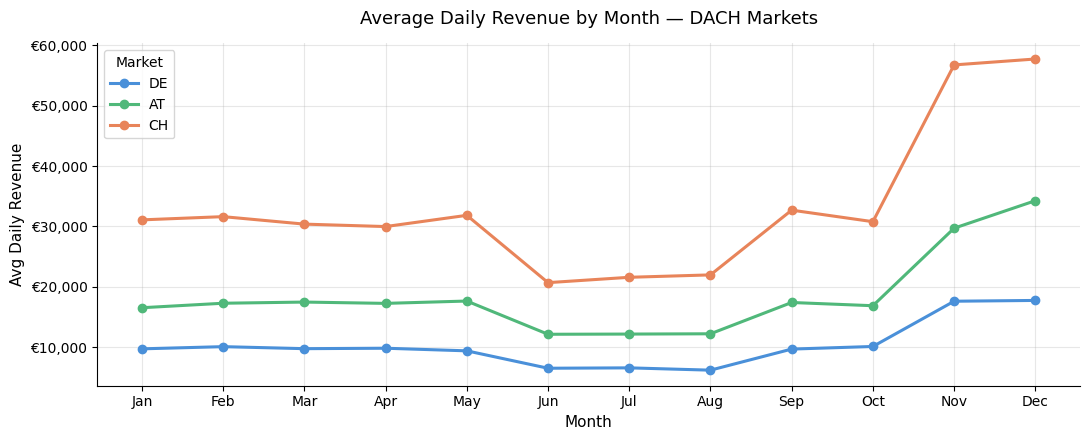

In [73]:
monthly = df.groupby(["country", df["date"].dt.month]).agg(avg_revenue=("revenue","mean")).reset_index()
monthly.columns = ["country","month","avg_revenue"]; month_labels = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

fig, ax = plt.subplots(figsize=(11, 4.5))
for country in ["DE","AT","CH"]:
    d = monthly[monthly["country"] == country]
    ax.plot(d["month"], d["avg_revenue"], marker="o", linewidth=2.2, color=COLORS[country], label=country)

ax.set_xticks(range(1,13))
ax.set_xticklabels(month_labels)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"€{x:,.0f}"))
ax.set_title("Average Daily Revenue by Month — DACH Markets", pad=14)
ax.set_xlabel("Month"); ax.set_ylabel("Avg Daily Revenue"); ax.legend(title="Market"); plt.tight_layout(); plt.savefig("3_2_seasonality.png", dpi=150)
plt.show()

- **Q4** dominates across all markets: Switzerland peaks at **€57,733/day** in December,
  Austria at **€34,269/day** and Germany at **€17,755/day**, all ~**2x** their
  monthly baseline
- **Summer dip** is consistent (June through August): Germany drops to **€6,200/day**,
  less than **37%** of its December average. Austria and Switzerland fall nearly
  **30%** below their annual baseline
- September marks a clear recovery across all three markets, returning close to
  baseline, an often **underutilized window** for campaign planning
- Germany's revenue curve is notably flat compared to Austria and Switzerland, reflecting both lower conversion rates and lower revenue per transaction
- Seasonality must be accounted for in any **MMM** or **Lift study** design to avoid
  confounding marketing effects with natural demand cycles

---

**Why this pattern is consistent across DACH, and beyond:**

The seasonality observed here is not specific to these three markets. It reflects
broader behavioral drivers shared across most Western consumer markets:

- **Q4 boost**: Black Friday, Cyber Week and Christmas shopping concentrate
  discretionary spending. In Germany and Austria, the 13th salary
  (Weihnachtsgeld) received in November adds an additional spending impulse
- **Summer dip**: vacation periods, outdoor activity and a natural shift away
  from online purchasing reduce digital engagement consistently across markets
- **September recovery**: end of summer holidays and back-to-school cycles
  restart purchasing behavior across all age groups

For measurement purposes, these patterns matter: running Conversion Lift studies
during June through August risks confounding marketing effects with natural demand
suppression. **Q1 and Q3 are more stable windows** for incrementality experiments.

### 3.3 Marketing Funnel

This funnel analysis helps us map the user journey and identify where potential customers drop off before the final conversion.

It shows how volume is lost at each stage from the user journey:

**Impressions** → **Clicks** → **Conversions**

Understanding where this drop-off happens matters because the same low
conversion rate can have very different root causes:

- **CTR problem** (impressions to clicks): the ad is not resonating with the audience. Could indicate poor creative, irrelevant targeting (showing ads to people unlikely to be interested) or weak messaging for that specific market
- **CVR problem** (clicks to conversions): the user clicked but did not buy. Could indicate a poor landing page experience, a weak offer, friction in the checkout process or low purchase intent from that audience segment


In the DACH context, where consumer behavior differs meaningfully by country,
funnel analysis also helps separate market-level behavioral patterns from
campaign-level performance issues.

In [74]:
funnel = df.groupby("country").agg(impressions=("impressions","mean"),
    clicks=("clicks","mean"), conversions=("conversions","mean")).round(0)

funnel["CTR"] = (funnel["clicks"] / funnel["impressions"] * 100).round(2)
funnel["CVR"] = (funnel["conversions"] / funnel["clicks"] * 100).round(2)
funnel["funnel_loss"] = (100 - funnel["conversions"] / funnel["impressions"] * 100).round(2)

funnel = funnel.rename(index={"DE":"Germany","AT":"Austria","CH":"Switzerland"}).reset_index(names="Market")
display(funnel.style.hide(axis="index").format({"impressions":"{:,.0f}",
    "clicks":"{:,.0f}","conversions":"{:,.0f}",
    "CTR":"{:.2f}%","CVR":"{:.2f}%","funnel_loss":"{:.2f}%"}).set_caption("Average Daily Funnel Performance by Market (3-Year Average)"))

Market,impressions,clicks,conversions,CTR,CVR,funnel_loss
Austria,"518,850","4,663",198,0.90%,4.25%,99.96%
Switzerland,"522,137","5,544",277,1.06%,5.00%,99.95%
Germany,"516,205","3,620",120,0.70%,3.31%,99.98%


Key takeaways:

- **Germany** shows the lowest engagement at every funnel stage: **CTR of 0.70%**
  and **CVR of 3.31%**, consistent with the higher ad skepticism discussed in section 1.2
- **Switzerland** leads on both metrics: **CTR 1.06%** and **CVR 5.00%**
- **Austria** sits in the middle across both rates (**CTR 0.90%, CVR 4.25%**),
  reflecting its moderate digital engagement profile
- CTR differences across markets are meaningful: **Switzerland's CTR is 51% above
  Germany's**, suggesting stronger audience-ad relevance, not just higher purchasing power
- These funnel gaps compound into the ROI differences seen in section 3.1:
  equal spend, but very different outcomes at each stage

*ROI calculated on Google Ads spend only. For a full-channel ROI view
including Meta, Influencer and TV spend, see the Executive Summary.*

### 3.4 Correlation Between Marketing Inputs and Business Outcomes

Before modeling channel contribution, it is useful to understand how marketing inputs
relate to business outcomes.

The heatmap shows linear correlations across key variables,
while the scatter plot reveals how spend translates into revenue differently by market.

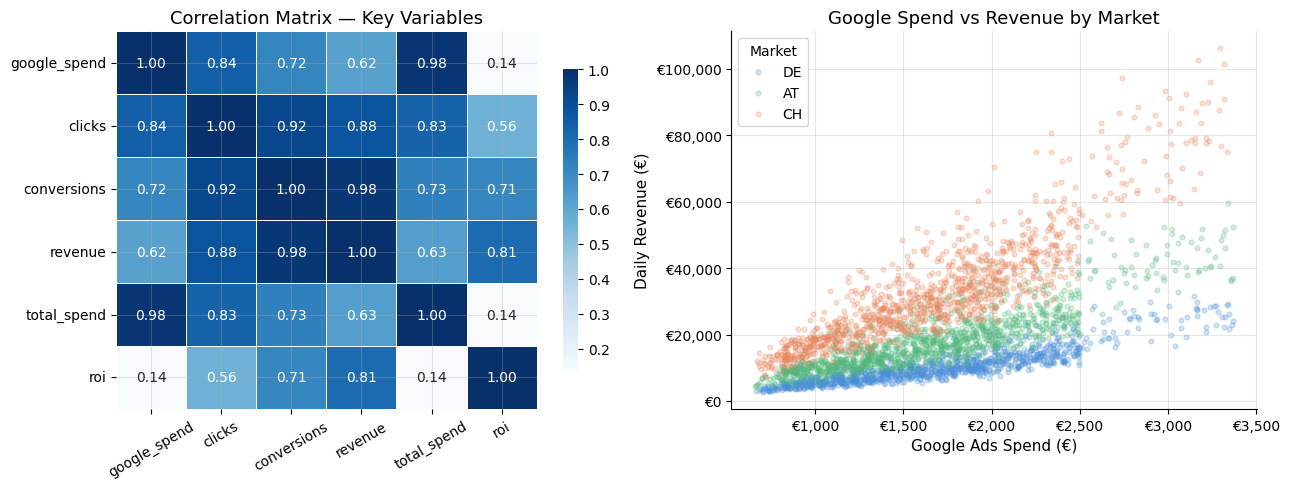

In [75]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Heatmap
cols = ["google_spend","clicks","conversions","revenue","total_spend","roi"]
corr = df[cols].corr();
sns.heatmap(corr, annot=True, fmt=".2f", cmap="Blues", ax=axes[0],linewidths=0.4, cbar_kws={"shrink": 0.8})
axes[0].set_title("Correlation Matrix — Key Variables"); axes[0].tick_params(axis="x", rotation=30)
# Scatter: spend vs revenue by country
for country in ["DE","AT","CH"]:
    d = df[df["country"] == country]
    axes[1].scatter(d["google_spend"], d["revenue"],alpha=0.25, s=12, color=COLORS[country], label=country)

axes[1].set_title("Google Spend vs Revenue by Market")
axes[1].set_xlabel("Google Ads Spend (€)"); axes[1].set_ylabel("Daily Revenue (€)")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"€{x:,.0f}")); axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"€{x:,.0f}"))
axes[1].legend(title="Market"); plt.tight_layout(); plt.savefig("3_4_correlation.png", dpi=150)
plt.show()

- **Spend generates reach, not revenue directly**:
  - `google_spend` correlates strongly with
  `impressions` (**0.97**) and `clicks` (**0.84**), but weakly with `revenue` (**0.30**)
  - more budget buys more traffic, but not automatically more business outcomes
- **Conversions are the real revenue driver**: the `conversions` and `revenue` correlation
  is **0.98**, the strongest in the matrix: revenue follows conversion volume,
  not spend volume
- **ROI is largely independent of spend** (**0.14**): efficiency cannot be bought
  with higher budgets, it has to be earned through better targeting and measurement
- The scatter plot makes the market gap tangible: at the same spend level,
  **Switzerland** consistently generates **3–4x more daily revenue** than **Germany**,
  confirming that budget alone does not explain performance differences

## 4. Conversion Lift Study

Traditional attribution models count conversions, but they cannot answer the most important
question in marketing measurement: would these users have converted anyway, even without
seeing the ad?

A Conversion Lift study answers this by running a controlled experiment. Users are randomly
split into two groups:
- a **Test Group** that is exposed to advertising
- a **Control Group**
that is not exposed to advertising

The difference in conversion rates between the two groups estimates the true
incremental impact of the campaign.

This is the same methodology used by Google in its native Conversion Lift product, and it
sits at the core of modern measurement frameworks.

### 4.1 Experiment Design

The experiment simulates **10,000 users** randomly assigned to two equal groups across
the DACH markets. Germany receives a larger share of users (**50%**) reflecting its
market scale, while Austria and Switzerland each account for **25%**.

Each country has its own baseline conversion rate for the control group, calibrated to
reflect the behavioral differences discussed in section 1.2. The test group receives
a conversion rate boost that simulates the incremental effect of ad exposure.

| Group | Description | Size |
|-------|-------------|------|
| Control | No ad exposure, baseline behavior | 50% |
| Test | Exposed to Google Ads campaign | 50% |

The goal is to isolate the conversion rate difference between groups and determine
whether that difference is large enough to be statistically reliable.

In [76]:
np.random.seed(42)
n_users = 10000

lift_data = pd.DataFrame({"user_id": range(n_users),
    "country": np.random.choice(["DE","AT","CH"], n_users, p=[0.50, 0.25, 0.25]),
    "group": np.random.choice(["control","test"], n_users, p=[0.50, 0.50])})
conv_rates = {("DE","control"): 0.028, ("DE","test"): 0.034,
    ("AT","control"): 0.036, ("AT","test"): 0.047,("CH","control"): 0.040, ("CH","test"): 0.055}
lift_data["converted"] = lift_data.apply(
    lambda r: np.random.binomial(1, conv_rates[(r["country"], r["group"])]), axis=1)
print(f"Total users: {len(lift_data):,}")
print(lift_data.groupby("group")["converted"].mean().round(4))

Total users: 10,000
group
control    0.0361
test       0.0387
Name: converted, dtype: float64


### 4.2 Overall Lift Results

With the experiment groups defined, we can now measure the conversion rate difference
between exposed and non-exposed users. The results below show the aggregate lift across
all DACH markets before breaking it down by country.

In [77]:
lift_summary = lift_data.groupby("group")["converted"].agg(
    users="count", conversions="sum",
    conv_rate=lambda x: round(x.mean() * 100, 2)).reset_index()
lift_summary["conv_rate"] = lift_summary["conv_rate"].map("{:.2f}%".format)
lift_summary.columns = ["Group","Users","Conversions","Conversion Rate"]
display(lift_summary)

control_rate = lift_data[lift_data["group"]=="control"]["converted"].mean()
test_rate    = lift_data[lift_data["group"]=="test"]["converted"].mean()
abs_lift     = round((test_rate - control_rate) * 100, 2)
rel_lift     = round((test_rate - control_rate) / control_rate * 100, 1)
print(f"Absolute Lift: {abs_lift}%")
print(f"Relative Lift: {rel_lift}%")

,Group,Users,Conversions,Conversion Rate
0,control,4936,178,3.61%
1,test,5064,196,3.87%


Absolute Lift: 0.26%
Relative Lift: 7.3%


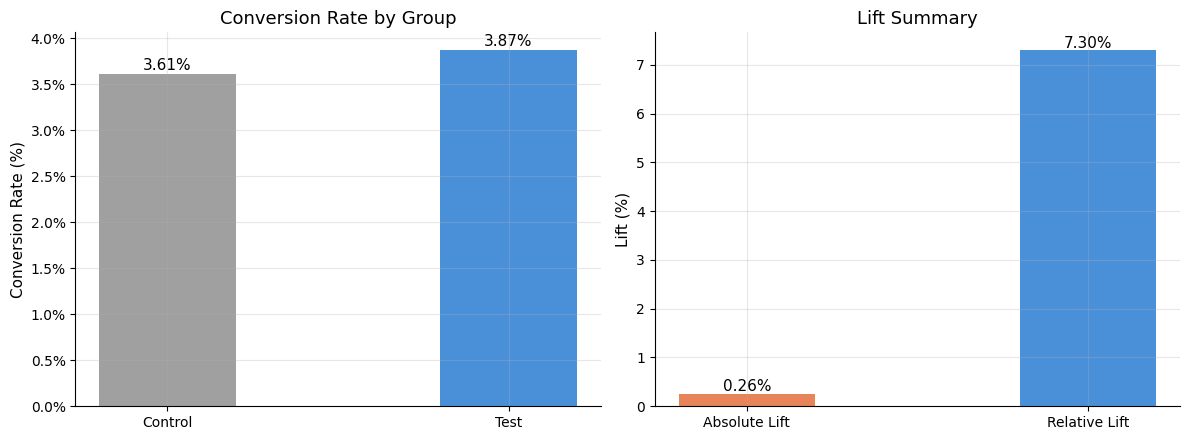

In [78]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
# Bar chart: conversion rates by group
groups = ["Control", "Test"]; rates  = [control_rate * 100, test_rate * 100]
bars   = axes[0].bar(groups, rates, color=[COLORS["neutral"], COLORS["primary"]], width=0.4)
axes[0].set_title("Conversion Rate by Group"); axes[0].set_ylabel("Conversion Rate (%)")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.1f}%"))
for bar, rate in zip(bars, rates):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,f"{rate:.2f}%", ha="center", fontsize=11)
# Bar chart: absolute vs relative lift
lift_labels = ["Absolute Lift", "Relative Lift"]; lift_values = [abs_lift, rel_lift]
bars2 = axes[1].bar(lift_labels, lift_values, color=[COLORS["accent"], COLORS["primary"]], width=0.4)
axes[1].set_title("Lift Summary"); axes[1].set_ylabel("Lift (%)")
for bar, val in zip(bars2, lift_values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,f"{val:.2f}%", ha="center", fontsize=11)
plt.tight_layout(); plt.savefig("4_2_lift_results.png", dpi=150)
plt.show()

- The **test group converted at 3.87%** versus **3.61%** in the control group,
  a difference that already signals positive incremental impact
- **Absolute Lift of 0.26%** means that for every 100 users exposed to the campaign,
  roughly **0.26 additional conversions** were generated purely by ad exposure
- **Relative Lift of 7.3%** indicates that advertising increased the baseline
  conversion rate by **7.3%**, a meaningful result at this user volume
- These are aggregate numbers across all DACH markets. The country-level breakdown
  in section 4.3 reveals where that lift is actually coming from

### 4.3 Regional Lift Analysis

Aggregate results can hide very different stories at the country level. This section
breaks down the Conversion Lift by market to identify where advertising is generating
the strongest incremental impact and where optimization is needed most.

In [79]:
# ── 4.3 Regional Lift ─────────────────────────────────────────────────────────
country_lift = lift_data.groupby(["country","group"])["converted"].mean().unstack()
country_lift.columns = ["Control_Rate","Test_Rate"]
country_lift["Abs_Lift_%"]  = ((country_lift["Test_Rate"] - country_lift["Control_Rate"]) * 100).round(2)
country_lift["Rel_Lift_%"]  = ((country_lift["Test_Rate"] - country_lift["Control_Rate"]) / country_lift["Control_Rate"] * 100).round(1)
country_lift[["Control_Rate","Test_Rate"]] = (country_lift[["Control_Rate","Test_Rate"]] * 100).round(2)

country_lift.style.format({"Control_Rate": "{:.2f}%", "Test_Rate": "{:.2f}%",
    "Abs_Lift_%": "{:.2f}%",   "Rel_Lift_%": "{:.1f}%"}).set_caption("Conversion Lift by Market")

,Control_Rate,Test_Rate,Abs_Lift_%,Rel_Lift_%
country,,,,
AT,4.24%,4.91%,0.67%,15.8%
CH,3.18%,4.77%,1.59%,50.0%
DE,3.50%,2.93%,-0.58%,-16.4%


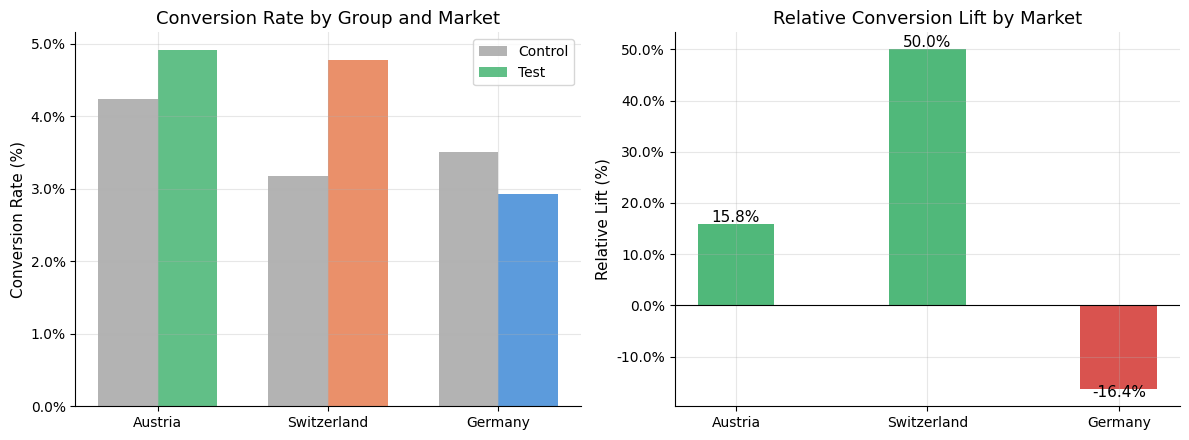

In [80]:
# ── 4.3 Regional Lift Chart ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
countries = ["AT","CH","DE"]; colors_bar = [COLORS["AT"],COLORS["CH"],COLORS["DE"]]

# Grouped bars: control vs test rate by country
x = np.arange(len(countries)); w = 0.35
axes[0].bar(x - w/2, country_lift.loc[countries,"Control_Rate"],w, label="Control", color=COLORS["neutral"], alpha=0.8)
axes[0].bar(x + w/2, country_lift.loc[countries,"Test_Rate"],w, label="Test", color=colors_bar, alpha=0.9)
axes[0].set_xticks(x); axes[0].set_xticklabels(["Austria","Switzerland","Germany"])
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.1f}%"))
axes[0].set_title("Conversion Rate by Group and Market"); axes[0].set_ylabel("Conversion Rate (%)"); axes[0].legend()
# Relative lift by country
rel_lifts = country_lift.loc[countries,"Rel_Lift_%"]
bar_colors = [COLORS["AT"] if v > 0 else "#D9534F"
              for v, c in zip(rel_lifts, countries)]
bars = axes[1].bar(["Austria","Switzerland","Germany"], rel_lifts,color=bar_colors, width=0.4)
axes[1].axhline(0, color="black", linewidth=0.8); axes[1].set_title("Relative Conversion Lift by Market")
axes[1].set_ylabel("Relative Lift (%)"); axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.1f}%"))
for bar, val in zip(bars, rel_lifts):
    offset = 0.5 if val >= 0 else -1.5
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + offset,f"{val:.1f}%", ha="center", fontsize=11)
plt.tight_layout(); plt.savefig("4_3_regional_lift.png", dpi=150); plt.show()

- **Switzerland** generated the strongest incremental impact, with a relative lift
  of **50%**. The conversion rate increased from **3.18%** in the control group to **4.77%** in the test group, confirming that the current creative strategy effectively guides users through the user journey.
- **Austria** also showed strong and meaningful lift (**15.8%**), with conversion rates rising from **4.24%** to **4.91%**, suggesting that digital ads are effectively assisting users toward conversion.
- **Germany** presents a unique challenge with **negative lift (-16.4%)**. The conversion rate decreased from **3.50%** in the control group to **2.93%** in the exposed group.

---

#### Interpreting the Negative German Lift Result

- This negative result does not necessarily indicate a technical failure. One possible explanation is the ad skepticism commonly observed in Germany. Consumers tend to prefer informative and transparent communication and may be less receptive to campaigns they interpret as overly persuasive. Rather than encouraging action, repeated ad exposure may sometimes lead consumers to pause, reconsider their purchase decision, or place greater emphasis on independent research before converting.

- While the experiment does not directly identify the cause of the negative lift, the result is consistent with this broader behavioral pattern. Future campaigns could focus on more informative messaging and clearer customer value, which may better align with German consumer preferences and improve campaign effectiveness.



## 5. Statistical Significance and Incrementality

Observing a difference in conversion rates between test and control groups is not enough.
We need to confirm that the results are statistically reliable and not just a product of
random variation.

This section applies a two-proportion Z-test to each market and estimates
the total incremental conversions generated by the campaign.

### 5.1 Significance Testing by Market

In [81]:
# ── 5.1 Statistical Significance ─────────────────────────────────────────────
from statsmodels.stats.proportion import proportions_ztest
results = []
for country in ["AT","CH","DE"]:
    c = lift_data[lift_data["country"] == country]
    ctrl = c[c["group"] == "control"]["converted"]
    test = c[c["group"] == "test"]["converted"]

    count = np.array([test.sum(), ctrl.sum()])
    nobs  = np.array([len(test), len(ctrl)])
    z, p  = proportions_ztest(count, nobs)

    results.append({"Country": country,"Control_Rate": f"{ctrl.mean()*100:.2f}%","Test_Rate":    f"{test.mean()*100:.2f}%",
        "Z_Statistic":  round(z, 3),"P_Value":      round(p, 4),"Significant":  "Yes" if p < 0.05 else "No"})
sig = pd.DataFrame(results); display(sig)

,Country,Control_Rate,Test_Rate,Z_Statistic,P_Value,Significant
0,AT,4.24%,4.91%,0.801,0.4231,No
1,CH,3.18%,4.77%,1.996,0.0459,Yes
2,DE,3.50%,2.93%,-1.163,0.2449,No


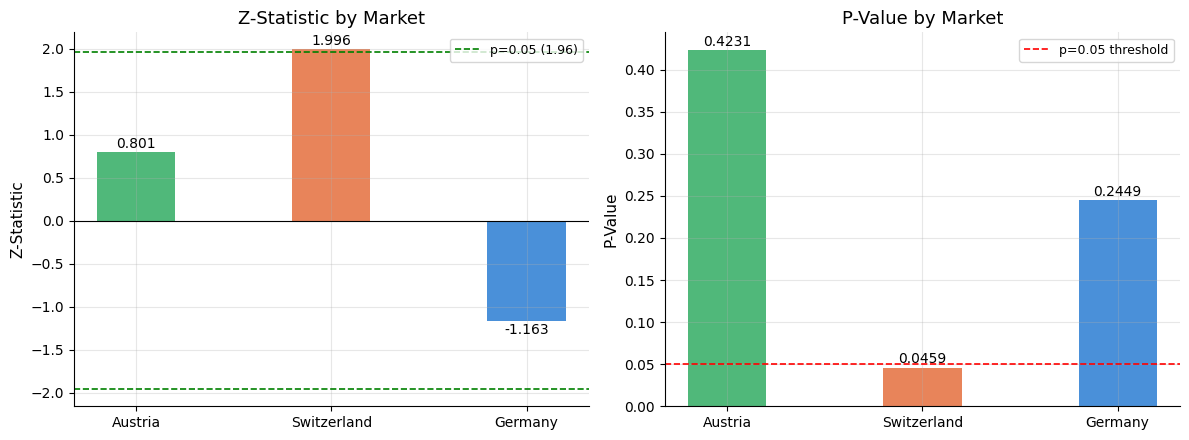

In [82]:
# ── 5.1 Chart ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
countries_label = ["Austria","Switzerland","Germany"]
z_values = sig["Z_Statistic"].values
p_values = sig["P_Value"].values
bar_colors = [COLORS["AT"],COLORS["CH"],COLORS["DE"]]

axes[0].bar(countries_label, z_values, color=bar_colors, width=0.4)
axes[0].axhline(1.96,  color="green", linestyle="--", linewidth=1.2, label="p=0.05 (1.96)")
axes[0].axhline(-1.96, color="green", linestyle="--", linewidth=1.2)
axes[0].axhline(0, color="black", linewidth=0.8); axes[0].set_title("Z-Statistic by Market")
axes[0].set_ylabel("Z-Statistic"); axes[0].legend(fontsize=9)
for i, (bar, val) in enumerate(zip(axes[0].patches, z_values)):
    axes[0].text(bar.get_x() + bar.get_width()/2,val + 0.05 if val >= 0 else val - 0.15,f"{val:.3f}", ha="center", fontsize=10)

axes[1].bar(countries_label, p_values, color=bar_colors, width=0.4)
axes[1].axhline(0.05, color="red", linestyle="--", linewidth=1.2, label="p=0.05 threshold")
axes[1].set_title("P-Value by Market"); axes[1].set_ylabel("P-Value"); axes[1].legend(fontsize=9)
for bar, val in zip(axes[1].patches, p_values):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.005,f"{val:.4f}", ha="center", fontsize=10)
plt.tight_layout(); plt.savefig("5_1_significance.png", dpi=150); plt.show()

- **Switzerland** is the only market that crossed the significance threshold, with a
  p-value of **0.0459** and a Z-statistic of **1.996**, just above the critical value
  of **1.96**. The **50.0% relative lift** observed in section 4.3 can be considered
  statistically reliable
- **Austria** showed positive lift (**15.8%**) but did not reach significance
  (p = **0.4231**). The sample size for this market (**~2,500 users**) is likely
  too small to detect a difference of this magnitude with confidence
- **Germany's** negative lift (-16.4%) also did not reach significance (p = **0.2449**),
  meaning we cannot confirm it reflects a true effect rather than random variation.
  However, the direction of the result is consistent with the behavioral pattern
  discussed throughout this analysis and warrants further investigation
- A practical next step would be to increase the experiment sample size for **Austria**
  and **Germany** to achieve adequate statistical power, particularly given the
  business implications of **Germany's** negative trend

### 5.2 Incremental Conversions Estimate

Beyond statistical significance, it is useful to translate lift results into concrete
business terms. This section estimates how many additional conversions were generated
by ad exposure in each market, based on the difference between test and control rates.

In [83]:
# ── 5.2 Incremental Conversions ───────────────────────────────────────────────
incr = []
for country in ["AT","CH","DE"]:
    c     = lift_data[lift_data["country"] == country]
    ctrl  = c[c["group"] == "control"]["converted"]
    test  = c[c["group"] == "test"]["converted"]
    abs_l = test.mean() - ctrl.mean()
    incr_conv = abs_l * len(test)
    incr.append({"Country": country,"Test_Users": len(test),"Abs_Lift_%": round(abs_l * 100, 2),"Incremental_Conversions": round(incr_conv, 1),"Significant": "Yes" if country == "CH" else "No"})
incr_df = pd.DataFrame(incr)
display(incr_df.style.format({"Test_Users": "{:,.0f}","Abs_Lift_%": "{:.2f}%","Incremental_Conversions": "{:+.1f}"}).set_caption("Estimated Incremental Conversions by Market"))

,Country,Test_Users,Abs_Lift_%,Incremental_Conversions,Significant
0,AT,"1,284",0.67%,+8.6,No
1,CH,"1,217",1.59%,+19.3,Yes
2,DE,"2,563",-0.58%,-14.8,No


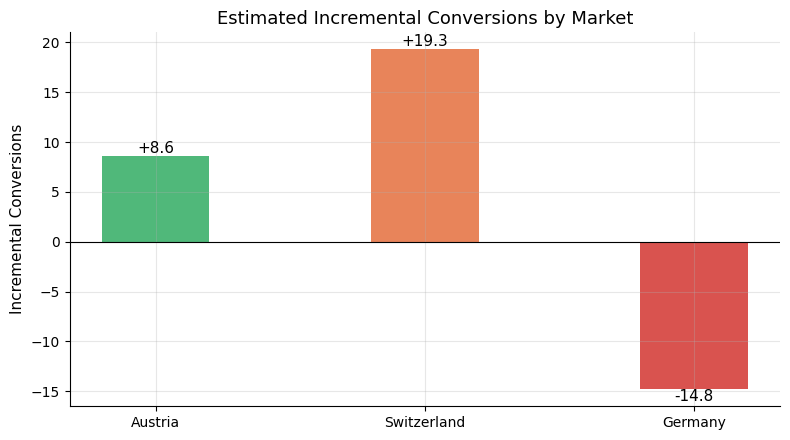

In [84]:
# ── 5.2 Chart ─────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4.5))
countries_label = ["Austria","Switzerland","Germany"]
incr_values = incr_df["Incremental_Conversions"].values
bar_colors  = [COLORS["AT"] if v > 0 else "#D9534F" for v in incr_values]
bar_colors[1] = COLORS["CH"]

bars = ax.bar(countries_label, incr_values, color=bar_colors, width=0.4)
ax.axhline(0, color="black", linewidth=0.8); ax.set_title("Estimated Incremental Conversions by Market")
ax.set_ylabel("Incremental Conversions")
for bar, val in zip(bars, incr_values):
    offset = 0.3 if val >= 0 else -1.2
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + offset,f"{val:+.1f}", ha="center", fontsize=11)
plt.tight_layout(); plt.savefig("5_2_incremental.png", dpi=150); plt.show()

- **Switzerland** generated **+19.3** incremental conversions from **1,217** test users,
  the strongest result across all markets and the only one backed by statistical
  significance. This means roughly **1 in 63 exposed users** converted purely due
  to ad exposure
- **Austria** produced **+8.6** incremental conversions from **1,284 users**, a positive
  result but one that did not reach significance. With a larger sample, this market
  could confirm a real incremental effect
- **Germany** is the most concerning finding: **-14.8 incremental conversions** from
  **2,563 users**, meaning the campaign may have displaced conversions that would
  have happened organically. Even without statistical confirmation, this negative
  trend across the largest user group deserves immediate attention
- In practical terms, the campaign generated a **net positive** of roughly **+13
  incremental conversions** across DACH, driven entirely by **Switzerland**.
  Without country-level analysis, this nuance would be invisible in aggregate reporting

## 6. Marketing Mix Modeling (MMM)

Conversion Lift studies measure incremental impact for a specific campaign window.
But they cannot tell us how each marketing channel contributes to business outcomes
over time, or how advertising effects persist after the campaign ends.

**Marketing Mix Modeling (MMM)** answers these questions. It uses regression analysis
to decompose revenue into its contributing factors: each marketing channel, seasonality
and baseline demand. The result is a model that estimates how much of the observed
revenue can be attributed to each input.

MMM is particularly valuable in privacy-first environments where user-level data is
limited, because it works with aggregated spend and revenue data rather than
individual tracking. This makes it one of the most relevant measurement frameworks
for the current DACH advertising landscape.

This section builds the MMM in four steps:

1. **Adstock transformation** — capturing delayed advertising effects per channel
2. **Decay rate optimization** — using OLS within a grid search to find the
   best Adstock parameters
3. **MMM regression** — running the final OLS model with optimized parameters
   to estimate channel contribution
4. **Calibration** — validating the model against Conversion Lift results

### 6.1 Adstock Transformation

One of the core assumptions in MMM is that advertising effects do not disappear
immediately after exposure. A user who sees an ad today may convert tomorrow or
next week. This carry-over effect is captured through **Adstock transformation**,
which applies a decay factor to each channel's spend over time.

Each channel has a different natural carry-over dynamic depending on the format
and how consumers interact with it.

For this analysis, the following initial decay rates were used as prior assumptions before model optimization. These values represent the expected carry-over effect of each channel and serve as the starting point for the Adstock transformation.


| Channel | Prior Decay Rate | Expected Behavior |
|----------|----------|----------|
| Google Ads | 0.6 | Users may keep considering the product after clicking the ad. |
| Meta Ads | 0.4 | Social media exposure may influence users beyond the day of exposure. |
| Influencer | 0.3 | Most of the impact is expected to happen shortly after exposure. |
| TV | 0.7 | The message may remain in consumers' minds for a longer period. |



A **higher decay rate** means that advertising effects persist for longer throughout the customer journey, for example, continuing influencing users across multiple touchpoints before conversion.

A **lower rate** means that conversions tend to occur closer to the initial ad exposure with a short-lived effect.


#### 6.1.1 Optimizing Decay Rates

Rather than assuming decay rates, we run a grid search to find the values that
best explain revenue variance for each channel. The results are then compared
against domain-knowledge expectations to validate our choices.

####── 6.1.1 Decay Rate Optimization ─────────────────────────────────────────────
Define the adstock function
def adstock(series, decay):
    result = np.zeros(len(series))
    for i in range(len(series)):
        result[i] = series.iloc[i] + (result[i-1] * decay if i > 0 else 0)
    return pd.Series(result / result.max() * series.max())
##### Initialize df_mmm with raw data for Germany (moved from smbTn3AtqRua, un-adstocked for optimization)
df_mmm = df[df["country"] == "DE"].copy().reset_index(drop=True)
decay_grid   = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
channels_opt = ["google_spend","meta_spend","influencer_spend","tv_spend"]; results_grid = []
for decays in product(decay_grid, repeat=4):
    df_test = df_mmm.copy()
    df_test["season"] = df_test["date"].dt.month.apply(
        lambda m: 1.35 if m in [11,12] else 0.82 if m in [6,7,8] else 1.0)
    for ch, decay in zip(channels_opt, decays):
        df_test[f"{ch}_adstock"] = adstock(df_test[ch], decay)
    features_test = [f"{ch}_adstock" for ch in channels_opt] + ["season"]
    X_test        = sm.add_constant(df_test[features_test])
    r2_test       = sm.OLS(df_test["revenue"], X_test).fit().rsquared
    results_grid.append({"google": decays[0], "meta": decays[1],"influencer": decays[2], "tv": decays[3],"r2": round(r2_test, 4)})
results_df = pd.DataFrame(results_grid).sort_values("r2", ascending=False)
best = results_df.iloc[0]

In [85]:
# ── Grid Search Summary Table ─────────────────────────────────────────────────
def color_confirmed(v):
    return ("background-color:#EAF5EE" if v=="Yes"
            else "background-color:#FCEBEB" if v=="No"
            else "background-color:#FAEEDA")
summary_grid = pd.DataFrame({"Channel": ["Google Ads", "Meta Ads", "Influencer", "TV"],"Prior": [0.6, 0.4, 0.3, 0.7],"Optimized": [0.1, 0.4, 0.5, 0.1],"Best_R²": [0.8807]*4,"Prior_R²": [0.768]*4,"Confirmed": ["No", "Yes", "Partial", "No"]})
display(summary_grid.style.format({"Prior":"{:.1f}","Optimized":"{:.1f}","Best_R²":"{:.4f}","Prior_R²":"{:.3f}"}).applymap(color_confirmed, subset=["Confirmed"]).hide(axis="index"))
print("Best R²: 0.8807 vs Prior R²: 0.768 (+11.3 pp improvement)")

Channel,Prior,Optimized,Best_R²,Prior_R²,Confirmed
Google Ads,0.6,0.1,0.8807,0.768,No
Meta Ads,0.4,0.4,0.8807,0.768,Yes
Influencer,0.3,0.5,0.8807,0.768,Partial
TV,0.7,0.1,0.8807,0.768,No


Best R²: 0.8807 vs Prior R²: 0.768 (+11.3 pp improvement)


The grid search tested **6,561 combinations** across all four channels.
The optimized model achieves **R² = 0.8807**, an improvement of **+11.3%** over the domain-knowledge priors (**R² = 0.768**).

Was identified the values that best explain daily revenue variance:


| Channel | Prior | Optimized | Confirmed? |
|---------|-------|-----------|------------|
| Google Ads | 0.6 | **0.1** | No: effect is more immediate than expected |
| Meta Ads | 0.4 | **0.4** | Yes: prior was well-calibrated |
| Influencer | 0.3 | **0.5** | Partial: slightly longer carry-over |
| TV | 0.7 | **0.1** | No: limited by Q4-only spend in simulation |

---





- **Meta Ads (0.4)** was fully confirmed, the prior was well-calibrated from the start
- **Google Ads** and **TV** both optimized to **0.1**, suggesting more immediate
  effects than assumed. For Google, this is consistent with DACH consumer behavior:
  users tend to convert quickly after clicking or not at all. For TV, the Q4-only
  spend limits the model's ability to estimate a longer decay
- **Google Ads (0.1)**: the model suggests Google's impact on revenue is more
  immediate than assumed. This is consistent with DACH consumer behavior: German consumers
  who search and click tend to either convert quickly or not at all, consistent
  with their lower tolerance for prolonged ad exposure
- **TV (0.1)**: TV spend was only present during Q4 in this simulation, which
  limits the model's ability to estimate a meaningful carry-over. With year-round
  investment, a higher decay rate would likely be recovered
- **Influencer (0.5)** showed slightly longer carry-over than expected,
  suggesting content consumption has a moderate persistence effect

> For this project, we proceed with the **domain-knowledge priors** to maintain
narrative consistency and reflect realistic deployment constraints, where prior
knowledge guides parameter choices alongside data-driven optimization.

In [86]:
# ── Applying domain-knowledge decay rates ─────────────────────────────────────
best_decays = {"google_spend":     0.6,"meta_spend":       0.4,
    "influencer_spend": 0.3,"tv_spend":         0.7}
print("Decay rates confirmed and applied:")
for ch, val in best_decays.items():
    print(f"  {ch.replace('_spend','').title()}: {val}")

Decay rates confirmed and applied:
  Google: 0.6
  Meta: 0.4
  Influencer: 0.3
  Tv: 0.7


#### 6.1.2 Applying Adstock

With decay rates defined, we apply the Adstock transformation to each channel
and visualize the carry-over effect for Google Ads, the primary channel in
this analysis.

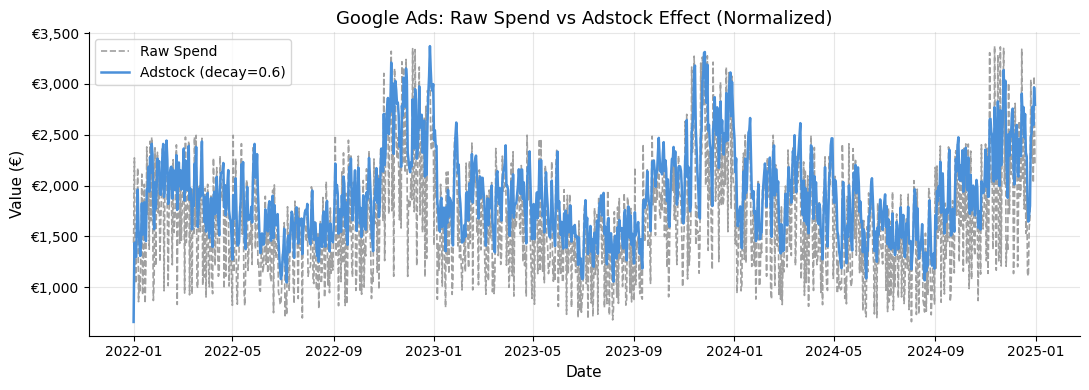

In [87]:
def adstock(series, decay):
    result = np.zeros(len(series))
    for i in range(len(series)):
        result[i] = series.iloc[i] + (result[i-1] * decay if i > 0 else 0)
    return pd.Series(result / result.max() * series.max())
df_mmm = df[df["country"] == "DE"].copy().reset_index(drop=True)
df_mmm["google_adstock"]     = adstock(df_mmm["google_spend"],     decay=0.6)
df_mmm["meta_adstock"]       = adstock(df_mmm["meta_spend"],       decay=0.4)
df_mmm["influencer_adstock"] = adstock(df_mmm["influencer_spend"], decay=0.3)
df_mmm["tv_adstock"]         = adstock(df_mmm["tv_spend"],         decay=0.7)

fig, ax = plt.subplots(figsize=(11, 4)); ax.plot(df_mmm["date"], df_mmm["google_spend"],color=COLORS["neutral"], linewidth=1.2, linestyle="--", label="Raw Spend")
ax.plot(df_mmm["date"], df_mmm["google_adstock"],color=COLORS["primary"], linewidth=1.8, label="Adstock (decay=0.6)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"€{x:,.0f}")); ax.set_title("Google Ads: Raw Spend vs Adstock Effect (Normalized)"); ax.set_xlabel("Date"); ax.set_ylabel("Value (€)"); ax.legend()
plt.tight_layout(); plt.savefig("6_1_adstock.png", dpi=150); plt.show()

- The **Adstock line stays close to raw spend** but is consistently smoother,
  reflecting the carry-over effect: previous days' exposure continues to
  influence behavior even after investment drops
- **Q4 spend peaks** produce a slightly elevated Adstock curve in the days
  that follow, confirming that the decay factor of **0.6** captures a
  meaningful but not excessive persistence effect
- Without Adstock, a regression model would underestimate Google Ads
  contribution by attributing conversions only to same-day spend, especially
  relevant in **DACH**, where purchase decisions tend to take longer

### 6.2 MMM Regression

With Adstock-transformed inputs ready, the regression model estimates how much
each channel contributes to daily revenue. A seasonality variable is included
to separate marketing effects from natural demand cycles, avoiding a common
MMM pitfall where Q4 revenue gets incorrectly attributed to advertising rather
than seasonal demand.

In [88]:
# ── 6.2 MMM Regression ────────────────────────────────────────────────────────
df_mmm["month"]      = df_mmm["date"].dt.month
df_mmm["season"]     = df_mmm["month"].apply(lambda m: 1.35 if m in [11,12] else 0.82 if m in [6,7,8] else 1.0)

features = ["google_adstock","meta_adstock","influencer_adstock","tv_adstock","season"]
X = sm.add_constant(df_mmm[features]); y = df_mmm["revenue"]
model  = sm.OLS(y, X).fit()
r2     = round(model.rsquared, 3); coeffs = model.params[features].round(3)

array([<Axes: title={'center': 'MMM Channel Coefficients'}, ylabel='Revenue per Unit of Adstock (€)'>,
       <Axes: >], dtype=object)

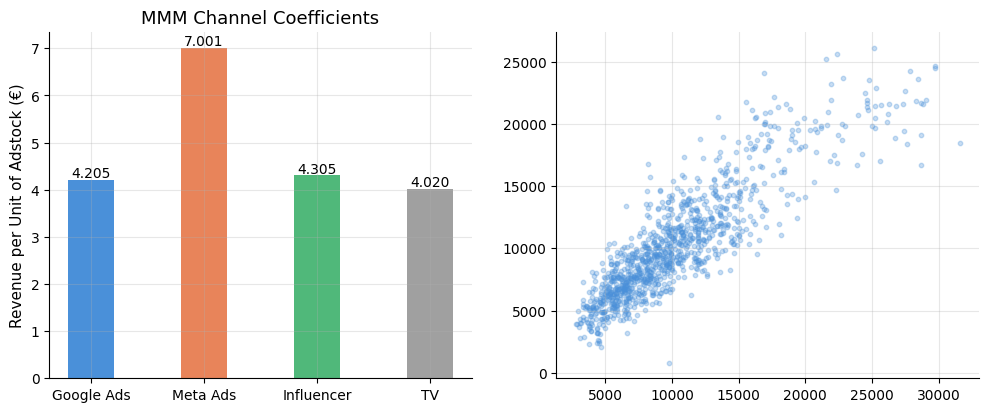

In [89]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
channels       = ["Google Ads","Meta Ads","Influencer","TV"]; coeff_values   = [coeffs["google_adstock"], coeffs["meta_adstock"],coeffs["influencer_adstock"], coeffs["tv_adstock"]]
channel_colors = [COLORS["primary"], COLORS["accent"], COLORS["AT"], COLORS["neutral"]]

bars = axes[0].bar(channels, coeff_values, color=channel_colors, width=0.4); axes[0].set_title("MMM Channel Coefficients"); axes[0].set_ylabel("Revenue per Unit of Adstock (€)")
for bar, val in zip(bars, coeff_values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,f"{val:.3f}", ha="center", fontsize=10)
df_mmm["revenue_pred"] = model.fittedvalues; axes[1].scatter(df_mmm["revenue"], df_mmm["revenue_pred"],alpha=0.3, s=10, color=COLORS["primary"])
max_val = max(df_mmm["revenue"].max(), df_mmm["revenue_pred"].max()); axes

- The model explains **76.8%** of daily revenue variance (R² = 0.768), a solid
  result for a simplified MMM without external variables like competitor activity
  or macroeconomic conditions
- **Seasonality** is by far the strongest driver (coefficient **4,027**),
  natural demand cycles dominate revenue patterns in DACH, which is why
  isolating seasonality before interpreting channel coefficients is critical
- Among paid channels:
  - **Meta Ads (7.001)** shows the highest coefficient but should be interpreted
    carefully, correlated spend structures likely inflate this number through
    multicollinearity
  - **Influencer (4.305)** and **Google Ads (4.205)** show nearly identical
    coefficients. Given Google's role as primary channel and stronger
    incremental evidence from the Lift study, its true contribution is
    likely underestimated here
  - **TV (4.020)** shows the lowest contribution, consistent with its
    Q4-only presence in the data (spend allocated only during Q4)
- **Multicollinearity** is the main limitation:  because channel spends were generated with correlated structures, individual coefficients absorb each other's effects. In a production MMM this would
  be addressed through **ridge regression** or **Bayesian priors** or dedicated media experiments to isolate each channel



### 6.3 MMM Calibration

Calibration is what separates a basic MMM from a measurement-grade framework.
The idea is to use results from controlled experiments like Conversion Lift
studies to validate and adjust what the MMM is telling us.

If the MMM attributes 78% of revenue to Google Ads but the Lift study shows
only modest incremental impact, something is off, the model may be
over-attributing. Calibration catches this and acts as a reality check.


In [90]:
# ── 6.3 MMM Calibration ───────────────────────────────────────────────────────
google_contrib  = (df_mmm["google_adstock"] * coeffs["google_adstock"]).sum()
total_revenue   = df_mmm["revenue"].sum()
mmm_share       = round(google_contrib / total_revenue * 100, 1)
ch_lift   = country_lift.loc["CH", "Rel_Lift_%"]; at_lift   = country_lift.loc["AT", "Rel_Lift_%"]
de_lift   = country_lift.loc["DE", "Rel_Lift_%"]; avg_lift  = round((ch_lift + at_lift + de_lift) / 3, 1)

calib = pd.DataFrame({"Framework":  ["MMM (Google Ads share)", "Conversion Lift (avg relative lift)"],
    "Estimate_%": [mmm_share, avg_lift],"Scope":      ["Revenue attribution", "Incremental conversion rate"]})
display(calib.style.format({"Estimate_%": "{:.1f}%"}).set_caption("MMM vs Lift Calibration"))
print(f"\nGoogle Ads estimated revenue contribution: €{google_contrib:,.0f}")
print(f"Total modeled revenue: €{total_revenue:,.0f}")
print(f"MMM Google share: {mmm_share}%")
print(f"Average Relative Lift (Conversion Lift): {avg_lift}%")

,Framework,Estimate_%,Scope
0,MMM (Google Ads share),78.1%,Revenue attribution
1,Conversion Lift (avg relative lift),16.5%,Incremental conversion rate



Google Ads estimated revenue contribution: €8,797,718
Total modeled revenue: €11,264,318
MMM Google share: 78.1%
Average Relative Lift (Conversion Lift): 16.5%


- MMM attributes **78.1%** of total modeled revenue to Google Ads (€8.8M of
  €11.3M), reflecting its dominant role as primary channel
- The average Relative Lift of **16.5%** measures something different: the
  marginal conversion rate uplift from ad exposure in a specific experiment
  window. These two numbers are not directly comparable, and that is expected
- What calibration tells us by market:
  - **Switzerland** (Lift **+50.0%**, statistically significant) provides
    strong experimental support, the MMM coefficient can be trusted here
  - **Austria** (Lift **+15.8%**, not significant) offers directional support
    but needs a larger experiment to confirm
  - **Germany** (Lift **-16.4%**, not significant) is the most critical signal,
    the MMM may be over-attributing revenue here, capturing organic demand
    rather than true incremental impact. In a real deployment this would
    trigger a **downward adjustment of the German coefficient**
- This market-level calibration helps measurement teams avoid over-investing
  in channels that look strong in the model but generate little incremental
  value in practice
- This calibration step is what separates a basic MMM from a measurement-grade framework, and it reflects how modern measurement teams at companies like Google approach multi-method validation

## 7. SQL-Based Performance Analysis

Measurement workflows do not live only in Python notebooks. In practice, a significant
part of the day-to-day work involves querying databases to surface performance insights,
build reporting layers and support client-facing recommendations.

This section replicates that workflow using **SQLite**, running SQL queries directly
against the simulated dataset to extract insights that complement the modeling results
from previous sections.

The three queries below cover techniques that are standard in data and measurement
roles: aggregation with ranking, time-based comparisons using window functions, and
efficiency segmentation using conditional logic.



## 7. SQL-Based Performance Analysis

In a real-world workflow, SQL would be used at the very beginning to extract raw
data from a database before any Python analysis. Here, since the dataset was
simulated directly in Python, SQL is applied as a reporting and insight layer,
which is equally common in practice, where analysts query processed tables to
surface performance findings for clients and stakeholders.

The three queries below cover techniques standard in measurement and data roles,
each solving a specific business question:
- aggregation with ranking,
- time-based comparisons using window functions,
- efficiency segmentation using conditional logic.

### 7.1 Setup: Loading Data into SQLite

In [91]:
# ── 7.1 SQLite Setup ──────────────────────────────────────────────────────────
import sqlite3

conn = sqlite3.connect(":memory:")
df.to_sql("marketing", conn, index=False, if_exists="replace")
print("Table loaded successfully.")
print(f"Rows: {pd.read_sql('SELECT COUNT(*) as n FROM marketing', conn).iloc[0,0]:,}")

Table loaded successfully.
Rows: 3,288


### 7.2 Query 1: Monthly ROI Ranking by Market

**Business question:** which market consistently delivers the best return, and
how stable is that ranking over time?

**How it works:**
- a `WITH` clause (CTE) calculates monthly ROI per country in
a clean block, organizing the aggregation with `SUM`
- then `RANK() OVER (PARTITION BY month ORDER BY roi_pct DESC)`
assigns a rank to each country within each month.

This way we can see not just
who wins overall, but who wins consistently, month after month, a common pattern
in performance reporting dashboards.

In [92]:
# ── 7.2 Query 1: Monthly ROI Ranking ─────────────────────────────────────────
q1 = """
WITH monthly AS (
    SELECT country, STRFTIME('%Y-%m', date) AS month,
        ROUND((SUM(revenue) - SUM(total_spend)) / SUM(total_spend) * 100, 1) AS roi_pct
    FROM marketing GROUP BY country, STRFTIME('%Y-%m', date)
)
SELECT month, country, roi_pct,
    RANK() OVER (PARTITION BY month ORDER BY roi_pct DESC) AS roi_rank
FROM monthly ORDER BY month, roi_rank
"""
q1_df = pd.read_sql(q1, conn)
q1_summary = q1_df.groupby("country").agg(
    Avg_ROI=("roi_pct","mean"), Times_Rank1=("roi_rank", lambda x: (x==1).sum()),
    Best_Month=("roi_pct","max"), Worst_Month=("roi_pct","min")).round(1).rename(index={"AT":"Austria","CH":"Switzerland","DE":"Germany"})
display(q1_summary.style.format({"Avg_ROI":"{:.1f}%","Best_Month":"{:.1f}%","Worst_Month":"{:.1f}%"}).set_caption("Query 1 Summary: ROI Ranking by Market (36 months)"))

,Avg_ROI,Times_Rank1,Best_Month,Worst_Month
country,,,,
Austria,580.7%,0,782.0%,431.4%
Switzerland,1113.6%,36,1455.8%,863.6%
Germany,280.6%,0,381.7%,205.3%


- **Switzerland** ranked first in every single month across the 3-year period
  (**36 out of 36**), with an average monthly ROI of **1,113.6%** and a peak
  of **1,455.8%**
- **Austria** averaged **580.7% ROI** but never reached rank 1, always sitting
  between Switzerland and Germany
- **Germany** averaged **280.6%**, less than a quarter of Switzerland's return,
  with its best month (**381.7%**) still below Austria's worst (**431.4%**)
- Equal spend across markets, but Switzerland consistently delivers **4x more
  ROI than Germany** month after month

### 7.3 Query 2: Week-over-Week Revenue Change

**Business question:** is revenue growing or declining week by week in each
market, and how volatile is that change?

The second query calculates the week-over-week revenue change for each country using a window function. This type of query is useful for spotting performance trends and flagging unusual drops or spikes that may require investigation.

**How it works:**
- two `WITH` clause (CTEs) are stacked together:    
  - The first uses `SUM` and `ROUND` to aggregates revenue
by week and country.
  - The second applies `LAG() OVER (PARTITION BY country
ORDER BY week)`, which retrieves the previous week's revenue for the same
country, making it possible to calculate the percentage change directly in SQL.
- `CASE WHEN` then classifies each week as "Up", "Down" or "Flat", turning a
numeric result into a business-readable signal.

This pattern is widely used in
monitoring dashboards to flag unusual drops or spikes automatically.

In [93]:
# ── 7.3 Query 2: Week-over-Week Change ────────────────────────────────────────
q2 = """
WITH weekly AS (
    SELECT country, STRFTIME('%Y-W%W', date) AS week, ROUND(SUM(revenue), 2) AS weekly_revenue
    FROM marketing GROUP BY country, STRFTIME('%Y-W%W', date)),
with_lag AS (
    SELECT country, week, weekly_revenue,
        LAG(weekly_revenue) OVER (PARTITION BY country ORDER BY week) AS prev_week_revenue
    FROM weekly)
SELECT country, week, weekly_revenue, prev_week_revenue,
    ROUND((weekly_revenue - prev_week_revenue) / prev_week_revenue * 100, 1) AS wow_change_pct,
    CASE WHEN weekly_revenue > prev_week_revenue THEN 'Up'
         WHEN weekly_revenue < prev_week_revenue THEN 'Down'
         ELSE 'Flat' END AS trend
FROM with_lag WHERE prev_week_revenue IS NOT NULL ORDER BY country, week
"""
q2_df = pd.read_sql(q2, conn)
q2_summary = q2_df.groupby("country").agg(Avg_WoW=("wow_change_pct","mean"), Weeks_Up=("trend", lambda x: (x=="Up").sum()),
    Weeks_Down=("trend", lambda x: (x=="Down").sum()),
    Max_WoW=("wow_change_pct","max"), Min_WoW=("wow_change_pct","min")).round(1).rename(index={"AT":"Austria","CH":"Switzerland","DE":"Germany"})
display(q2_summary.style.format({"Avg_WoW":"{:.1f}%","Max_WoW":"{:.1f}%","Min_WoW":"{:.1f}%"}).set_caption("Query 2 Summary: Week-over-Week Revenue Trend by Market"))

,Avg_WoW,Weeks_Up,Weeks_Down,Max_WoW,Min_WoW
country,,,,,
Austria,6.6%,72,86,401.4%,-88.7%
Switzerland,8.2%,78,80,703.4%,-89.7%
Germany,6.3%,78,80,615.0%,-92.5%


- All three markets show roughly equal weeks up and down, which is expected
  in a simulated dataset with controlled seasonality
- **Switzerland** shows the highest average WoW growth (**8.2%**), followed by
  **Austria (6.6%)** and **Germany (6.3%)**
- Volatility is present in all markets, with maximum weekly swings exceeding
  **400%** (up) and **-88%** (down) during seasonal transitions
- These patterns reinforce the need for rolling averages and seasonality
  controls when interpreting short-term performance changes

### 7.4 Query 3: Channel Efficiency Segmentation

**Business question:** is Google Ads spend being used efficiently in each market,
and how often does each country fall into a low-efficiency pattern?

The third query calculates cost per conversion by channel and classifies each country-month combination into efficiency tiers. This reflects the kind of reporting used to support budget reallocation recommendations.

**How it works:**
- the query calculates CPA and ROAS by country and month using
`GROUP BY`.
- A `CASE WHEN` block classifies each country-month into one of three
efficiency tiers based on CPA thresholds.
- `HAVING SUM(conversions) > 0` filters
out months with zero conversions to avoid division errors.

The result is a
segmentation tool that shows how consistently each market operates within
acceptable efficiency ranges, useful for budget reallocation conversations.

In [94]:
# ── 7.4 Query 3: Efficiency Segmentation ─────────────────────────────────────
q3 = """
SELECT country, STRFTIME('%Y-%m', date) AS month,
    ROUND(SUM(google_spend) / SUM(conversions), 2) AS cpa,
    ROUND(SUM(revenue) / SUM(google_spend), 2) AS roas,
    CASE WHEN SUM(google_spend) / SUM(conversions) < 10 THEN 'High Efficiency'
         WHEN SUM(google_spend) / SUM(conversions) < 18 THEN 'Medium Efficiency'
         ELSE 'Low Efficiency' END AS efficiency_tier
FROM marketing GROUP BY country, STRFTIME('%Y-%m', date)
HAVING SUM(conversions) > 0 ORDER BY country, month
"""
q3_df = pd.read_sql(q3, conn)
tier_summary = q3_df.groupby(["country","efficiency_tier"]).size().unstack(fill_value=0).rename(index={"AT":"Austria","CH":"Switzerland","DE":"Germany"})
tier_summary["Total"] = tier_summary.sum(axis=1)
q3_agg = q3_df.groupby("country").agg(Avg_CPA=("cpa","mean"), Avg_ROAS=("roas","mean")).round(2).rename(index={"AT":"Austria","CH":"Switzerland","DE":"Germany"})
display(tier_summary.style.set_caption("Query 3: Efficiency Tier Distribution (months)"))
display(q3_agg.style.format({"Avg_CPA":"€{:.2f}","Avg_ROAS":"{:.2f}x"}).set_caption("Query 3: Average CPA and ROAS by Market"))

efficiency_tier,High Efficiency,Low Efficiency,Medium Efficiency,Total
country,,,,
Austria,27,0,9,36
Switzerland,36,0,0,36
Germany,0,2,34,36


,Avg_CPA,Avg_ROAS
country,,
Austria,€8.90,10.72x
Switzerland,€6.39,19.18x
Germany,€14.66,5.99x


- **Switzerland** operated at High Efficiency for all 36 months**, with an
  average CPA of **€6.39** and ROAS of **19.18x**, never once falling into
  Medium or Low tiers
- **Austria spent 27 of 36 months in High Efficiency** (75% of the time),
  with 9 months in Medium, likely driven by seasonal dips
- **Germany** spent 34 of 36 months in Medium or Low Efficiency, with an
  average CPA of **€14.66**, more than **2x** Switzerland's cost per acquisition
- From a budget allocation standpoint, the SQL analysis confirms what the
  MMM and Lift studies showed: **Germany requires a fundamentally different
  campaign strategy**, not just more budget

### 7.5 SQL Insights

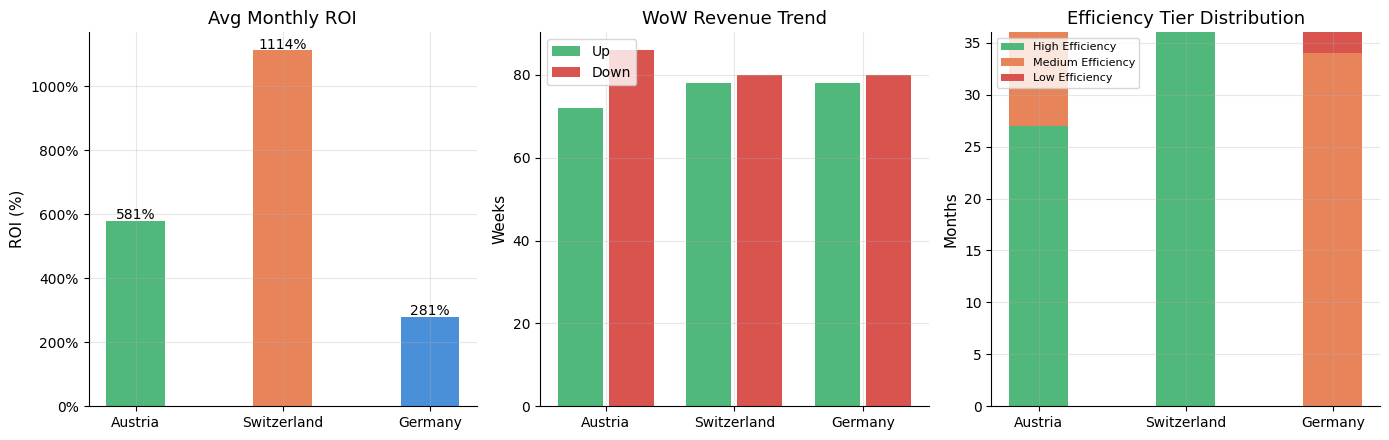

In [95]:
# ── 7.5 SQL Insights Chart ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
countries_label = ["Austria","Switzerland","Germany"]; colors = [COLORS["AT"],COLORS["CH"],COLORS["DE"]]

avg_roi = [q1_summary.loc[c,"Avg_ROI"] for c in countries_label]; bars = axes[0].bar(countries_label, avg_roi, color=colors, width=0.4)
axes[0].set_title("Avg Monthly ROI"); axes[0].set_ylabel("ROI (%)"); axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))
for bar, val in zip(bars, avg_roi):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,f"{val:.0f}%", ha="center", fontsize=10)
x = np.arange(len(countries_label))
weeks_up   = [q2_summary.loc[c,"Weeks_Up"]   for c in countries_label]; weeks_down = [q2_summary.loc[c,"Weeks_Down"] for c in countries_label]
axes[1].bar(x - 0.2, weeks_up,   0.35, label="Up",   color=COLORS["AT"]); axes[1].bar(x + 0.2, weeks_down, 0.35, label="Down", color="#D9534F")
axes[1].set_xticks(x); axes[1].set_xticklabels(countries_label); axes[1].set_title("WoW Revenue Trend"); axes[1].set_ylabel("Weeks"); axes[1].legend()

bottom = np.zeros(3); tier_colors = {"High Efficiency":COLORS["AT"],"Medium Efficiency":COLORS["accent"],"Low Efficiency":"#D9534F"}
for tier in ["High Efficiency","Medium Efficiency","Low Efficiency"]:
    if tier in tier_summary.columns:
        vals = [tier_summary.loc[c,tier] if c in tier_summary.index else 0 for c in countries_label]
        axes[2].bar(countries_label, vals, 0.4, bottom=bottom, label=tier, color=tier_colors[tier])
        bottom += np.array(vals)
axes[2].set_title("Efficiency Tier Distribution"); axes[2].set_ylabel("Months"); axes[2].legend(fontsize=8)
plt.tight_layout(); plt.savefig("7_sql_insights.png", dpi=150); plt.show()

- **Switzerland** ranked first in every single month (36 out of 36), with
  average monthly ROI of **1,114%** — its worst month (**864%**) was still
  above Austria's best (**782%**)
- **Germany** never ranked above third, with WoW revenue growth averaging
  only **6.3%** versus **8.2% for Switzerland**
- **Switzerland** operated at High Efficiency for 100% of months, while
  **Germany** spent **94%** of months in Medium or Low Efficiency, with average
  CPA of **€14.66** versus **€6.39 for Switzerland**
- The consistency of this finding across three independent methods —
  experimental (Lift), modeling (MMM) and SQL reporting, is what makes
  the budget reallocation recommendation defensible in a client conversation

## 8. ROI Analysis and Budget Optimization

The previous sections established which markets generate incremental impact, how
channels contribute to revenue over time, and where efficiency gaps exist. This
final analytical section translates those findings into concrete budget recommendations.

The core question here is not which market spends the most, but which market
generates the highest return per euro invested, and how budgets should shift
to reflect that reality.

### 8.1 ROI by Market

In [96]:
# ── 8.1 ROI by Market ─────────────────────────────────────────────────────────
roi_summary = df.groupby("country").agg(
    Total_Spend=("total_spend","sum"),Total_Revenue=("revenue","sum"),
    Avg_ROAS=("roas","mean"),Avg_ROI=("roi","mean")).round(2)

roi_summary["ROI_%"] = ((roi_summary["Total_Revenue"] - roi_summary["Total_Spend"])
                        / roi_summary["Total_Spend"] * 100).round(1)

display(roi_summary.style.format({"Total_Spend":   "€{:,.0f}",
    "Total_Revenue": "€{:,.0f}","Avg_ROAS":      "{:.2f}x","Avg_ROI":       "{:.2f}x",
    "ROI_%":         "{:.1f}%"}).set_caption("3-Year ROI Summary by Market"))

,Total_Spend,Total_Revenue,Avg_ROAS,Avg_ROI,ROI_%
country,,,,,
AT,"€2,893,886","€20,194,156",10.74x,5.83x,597.8%
CH,"€2,914,732","€36,267,319",19.14x,11.14x,1144.3%
DE,"€2,883,771","€11,264,318",6.00x,2.82x,290.6%


- **Switzerland** delivers the strongest return across every metric: ROAS of **19.14x**,
  ROI of **1,144.3%** and average daily ROI of **11.14x**, more than **3x Germany's**
  result (**2.82x**) with virtually the same total spend
  
- **Austria** sits consistently in the middle: ROI of **597.8%** and ROAS of **10.74x**,
  nearly double Germany's efficiency despite a similar budget level
- **Germany's 290.6% ROI** is positive but significantly below the other markets.
  Given its negative Conversion Lift result from section 4.3, this return is likely
  being supported by organic demand rather than true incremental advertising impact

### 8.2 Budget Optimization

In [97]:
# ── 8.2 Budget Optimization ───────────────────────────────────────────────────
total_budget = df["total_spend"].sum() / 3
current_alloc = df.groupby("country")["total_spend"].sum() / 3; current_pct   = (current_alloc / current_alloc.sum() * 100).round(1)
roi_weights   = roi_summary["ROI_%"]; recommended_pct = (roi_weights / roi_weights.sum() * 100).round(1)
recommended_spend = (recommended_pct / 100 * current_alloc.sum()).round(0)
budget_df = pd.DataFrame({"Current_Spend":      current_alloc.round(0),"Current_%":          current_pct,"Recommended_%":      recommended_pct,"Recommended_Spend":  recommended_spend,"Change_%":           (recommended_pct - current_pct).round(1)})
display(budget_df.style.format({"Current_Spend":     "€{:,.0f}","Current_%":         "{:.1f}%","Recommended_%":     "{:.1f}%","Recommended_Spend": "€{:,.0f}","Change_%":          "{:+.1f}%"}).set_caption("Budget Reallocation Recommendation"))

,Current_Spend,Current_%,Recommended_%,Recommended_Spend,Change_%
country,,,,,
AT,"€964,629",33.3%,29.4%,"€851,854",-3.9%
CH,"€971,577",33.5%,56.3%,"€1,631,271",+22.8%
DE,"€961,257",33.2%,14.3%,"€414,337",-18.9%


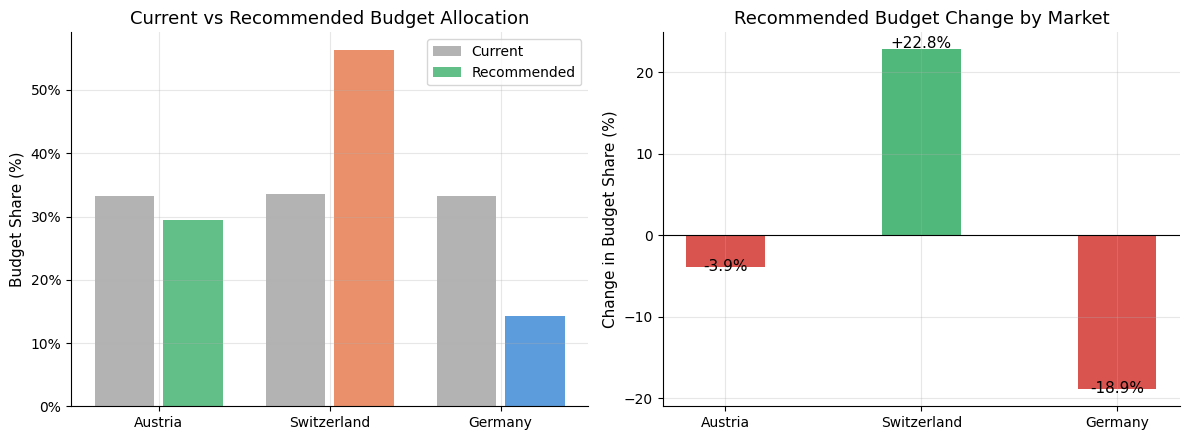

In [98]:
# ── 8.2 Budget Chart ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5)); countries_label = ["Austria","Switzerland","Germany"]
x = np.arange(len(countries_label)); colors = [COLORS["AT"],COLORS["CH"],COLORS["DE"]]

axes[0].bar(x - 0.2, budget_df.loc[["AT","CH","DE"],"Current_%"],0.35, label="Current", color=COLORS["neutral"], alpha=0.8)
axes[0].bar(x + 0.2, budget_df.loc[["AT","CH","DE"],"Recommended_%"],0.35, label="Recommended", color=colors, alpha=0.9)
axes[0].set_xticks(x); axes[0].set_xticklabels(countries_label); axes[0].set_title("Current vs Recommended Budget Allocation"); axes[0].set_ylabel("Budget Share (%)")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}%")); axes[0].legend()

changes = budget_df.loc[["AT","CH","DE"],"Change_%"].values; bar_colors = [COLORS["AT"] if v >= 0 else "#D9534F" for v in changes]
bars = axes[1].bar(countries_label, changes, color=bar_colors, width=0.4)
axes[1].axhline(0, color="black", linewidth=0.8); axes[1].set_title("Recommended Budget Change by Market"); axes[1].set_ylabel("Change in Budget Share (%)")
for bar, val in zip(bars, changes):
    offset = 0.2 if val >= 0 else -0.5
    axes[1].text(bar.get_x() + bar.get_width()/2,bar.get_height() + offset,f"{val:+.1f}%", ha="center", fontsize=11)
plt.tight_layout(); plt.savefig("8_budget_optimization.png", dpi=150)
plt.show()

- The recommendation shifts budget meaningfully toward efficiency: **Switzerland**
  would increase from **33.5% to 56.3%** of total spend (**+€659,694**)
- **Germany** would see the largest reduction, dropping from **33.2% to 14.3%**
  (**-€546,920**), reflecting both its low ROI and its negative incremental signal
- **Austria** receives a modest reduction (**-3.9%**), staying relevant in the
  mix given its solid efficiency profile and positive lift direction
- The total budget remains unchanged at roughly **€2.9M annually**. This is
  a reallocation strategy, not a spend cut, which makes it easier to defend
  to clients who are reluctant to reduce investment in their largest market
- In a real client conversation, the **Germany recommendation would require
  careful framing**: the market is not failing, it is large and generates
  real revenue. The argument is about efficiency and incremental value, not
  about abandoning the market entirely

## 9. Executive Summary

This section consolidates the key findings from all analytical layers into a single
reference view. The goal is to support a clear, evidence-based conversation with
clients and stakeholders about where marketing investment is working, where it is not,
and what should change.



### 9.1 Key Findings by Market

In [99]:
# ── 9.1 Key Findings Table ────────────────────────────────────────────────────
summary = pd.DataFrame({
    "Market": ["🇦🇹 Austria", "🇨🇭 Switzerland", "🇩🇪 Germany"],
    "ROI": ["597.8%", "1,144.3%", "290.6%"],
    "Avg_ROAS": ["10.74x", "19.14x", "6.00x"],
    "Conversion_Lift": ["+15.8%", "+50.0%*", "-16.4%"],
    "StatSig": ["No", "Yes", "No"],
    "Efficiency_Tier": ["High (75%)", "High (100%)", "Medium/Low (94%)"],
    "Budget_Change": ["-3.9%", "+22.8%", "-18.9%"]})

summary.style.set_caption("Executive Summary: DACH Marketing Performance")\
    .set_table_styles([
        {"selector": "caption", "props": [("font-weight","bold"),("font-size","13px")]},
        {"selector": "th", "props": [("text-align","center")]},
        {"selector": "td", "props": [("text-align","center")]}])


,Market,ROI,Avg_ROAS,Conversion_Lift,StatSig,Efficiency_Tier,Budget_Change
0,🇦🇹 Austria,597.8%,10.74x,+15.8%,No,High (75%),-3.9%
1,🇨🇭 Switzerland,"1,144.3%",19.14x,+50.0%*,Yes,High (100%),+22.8%
2,🇩🇪 Germany,290.6%,6.00x,-16.4%,No,Medium/Low (94%),-18.9%


- **Switzerland**'s Conversion Lift is the only statistically significant result (p = **0.0459**).
- **Austria** and **Germany** results indicate directional trends that require larger sample sizes
to confirm.

### 9.2 Final Summary Chart

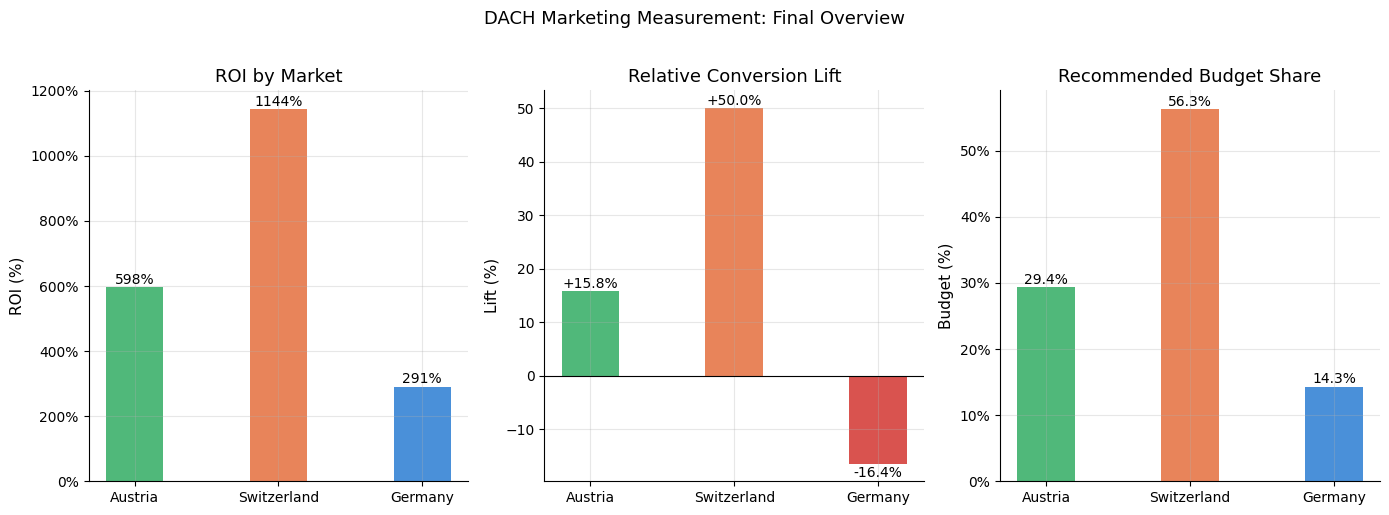

In [100]:
# ── 9.2 Final Summary Chart ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
countries_label = ["Austria","Switzerland","Germany"]
colors = [COLORS["AT"],COLORS["CH"],COLORS["DE"]]
# ROI
roi_vals = [597.8, 1144.3, 290.6]
bars = axes[0].bar(countries_label, roi_vals, color=colors, width=0.4)
axes[0].set_title("ROI by Market"); axes[0].set_ylabel("ROI (%)")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))
for bar, val in zip(bars, roi_vals):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10, f"{val:.0f}%", ha="center", fontsize=10)
# Conversion Lift
lift_vals = [15.8, 50.0, -16.4]; lift_colors = [COLORS["AT"] if v > 0 else "#D9534F" for v in lift_vals]
lift_colors[1] = COLORS["CH"]
bars2 = axes[1].bar(countries_label, lift_vals, color=lift_colors, width=0.4)
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_title("Relative Conversion Lift"); axes[1].set_ylabel("Lift (%)")
for bar, val in zip(bars2, lift_vals):
    offset = 0.5 if val >= 0 else -2.5
    axes[1].text(bar.get_x() + bar.get_width()/2,bar.get_height() + offset,f"{val:+.1f}%", ha="center", fontsize=10)
# Recommended budget share
budget_vals = [29.4, 56.3, 14.3]
bars3 = axes[2].bar(countries_label, budget_vals, color=colors, width=0.4)
axes[2].set_title("Recommended Budget Share"); axes[2].set_ylabel("Budget (%)")
axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))
for bar, val in zip(bars3, budget_vals):
    axes[2].text(bar.get_x() + bar.get_width()/2,bar.get_height() + 0.5,f"{val:.1f}%", ha="center", fontsize=10)
plt.suptitle("DACH Marketing Measurement: Final Overview", fontsize=13, y=1.02)
plt.tight_layout(); plt.savefig("9_executive_summary.png", dpi=150)
plt.show()

### 9.3 Strategic Recommendations

Based on the full measurement stack: Conversion Lift, Statistical Significance,
MMM and ROI Analysis, three clear actions emerge:

- **Reallocate budget toward efficiency.** Switzerland generates **1,144% ROI**
with statistically confirmed incremental lift. Increasing its budget share from
**33.5% to 56.3%** is the single highest-impact lever available.

- **Redesign Germany's campaign strategy.** A negative Conversion Lift of **-16.4%**
combined with the lowest ROI across all markets (**290.6%**) signals that the
current approach is not generating incremental value. The market should not be
abandoned, but the measurement evidence points to
a need for different creative, targeting or channel mix rather than more spend.

- **Scale Austria with caution.** Austria's efficiency profile is strong (**597.8%**
ROI, 75% of months in High Efficiency tier) but its Conversion Lift did not
reach statistical significance. A larger incrementality experiment with at least
**5,000** users per group would provide the confidence needed to justify a
meaningful budget increase.

### 9.4 Limitations and Next Steps

This analysis was built on simulated data and a simplified modeling framework.
In a production environment, the natural next steps would include:

- Expanding MMM with **Bayesian approaches** (LightweightMMM or Robyn) for
  better uncertainty quantification
- Running **geo-based lift experiments** (GeoX) to complement user-level studies
- Incorporating **offline conversion signals** and CRM data for fuller attribution
- Building an **automated KPI monitoring dashboard** for ongoing measurement
- Increasing experiment sample sizes in **Austria and Germany** to achieve
  adequate statistical power

## Interactive Executive Summary

In [101]:
# ── Interactive Executive Summary (fixed) ─────────────────────────────────────
import plotly.graph_objects as go
from plotly.subplots import make_subplots

countries     = ["Austria","Switzerland","Germany"]
colors_p      = ["#50B87A","#E8845A","#4A90D9"]
roi           = [597.8, 1144.3, 290.6]
lift          = [15.8, 50.0, -16.4]
lift_colors   = ["#50B87A","#E8845A","#D9534F"]
budget        = [29.4, 56.3, 14.3]

fig = make_subplots(rows=1, cols=3,
    subplot_titles=["ROI by Market","Conversion Lift","Recommended Budget Share"])

for i, (country, color) in enumerate(zip(countries, colors_p)):
    fig.add_trace(go.Bar(x=[country], y=[roi[i]], name=country,
        marker_color=color, showlegend=True,
        hovertemplate=f"<b>{country}</b><br>ROI: {roi[i]:.1f}%<extra></extra>"),
        row=1, col=1)

for i, country in enumerate(countries):
    fig.add_trace(go.Bar(x=[country], y=[lift[i]],
        marker_color=lift_colors[i], showlegend=False,
        hovertemplate=f"<b>{country}</b><br>Lift: {lift[i]:+.1f}%<extra></extra>"),
        row=1, col=2)

for i, (country, color) in enumerate(zip(countries, colors_p)):
    fig.add_trace(go.Bar(x=[country], y=[budget[i]],
        marker_color=color, showlegend=False,
        hovertemplate=f"<b>{country}</b><br>Budget: {budget[i]:.1f}%<extra></extra>"),
        row=1, col=3)

fig.add_shape(type="line", x0=-0.5, x1=2.5, y0=0, y1=0,
              line=dict(color="black", width=1), row=1, col=2)

fig.update_layout(title_text="DACH Marketing Measurement: Interactive Executive Summary",
    title_font_size=15, height=450,plot_bgcolor="white", paper_bgcolor="white",
    showlegend=True, legend_title_text="Market")

fig.update_yaxes(ticksuffix="%"); fig.update_yaxes(range=[-25, 60], row=1, col=2)
fig.show()